# Plant-wide optimization of a multi-area `ProcessModel`

This notebook demonstrates the **agentic optimization workflow** on a large multi-area
NeqSim `ProcessModel` — the same pattern used to optimize real offshore plants such as the
**Oseberg Sture low-pressure operation** model (a ~13-area `ProcessModel` with separation,
recompression, export and injection trains).

The Oseberg production model cannot be executed here because it depends on external,
site-specific data files. Instead we build a **self-contained, representative two-area**
`ProcessModel` (separation + recompression/export) that exercises the **identical Java APIs**,
so the workflow transfers one-to-one to the full plant.

## What this notebook shows

| Step | API | Purpose |
|------|-----|---------|
| Build | `ProcessModel.add(name, system)` | compose named process areas |
| Observe (empty) | `getUtilizationSnapshotJson()` | utilization is **zero** until capacity limits exist |
| Size | `autoSizeEquipment(safety)` | size every unit in every area in one call |
| **Activate** | **`applyMechanicalDesignCapacityConstraints()`** | **NEW: one call activates utilization across the whole plant** |
| Observe (live) | `getUtilizationSnapshotJson()` | bottleneck + per-unit utilization |
| Discover | `getAdjustableParametersJson()` | bounded decision space |
| Optimize | `getAutomation().evaluate(setpoints, unit, readbacks)` | gated, never-throwing optimizer step |
| Spec | `Standard_ASTM_D6377` (RVP) | export-oil quality constraint via penalty |

The heavy lifting (sizing, constraint construction, convergence, feasibility gating) happens
**inside Java NeqSim** — Python only *builds the plant*, *drives setpoints*, and *reads results*.

In [1]:
import os, sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
            return candidate
    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")


PROJECT_ROOT = find_neqsim_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)
print("NeqSim loaded from workspace classes")

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.13.0.jar



JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes


All NeqSim classes imported OK
NeqSim loaded from workspace classes


In [2]:
import json
import jpype

SystemSrkEos = ns.SystemSrkEos
ProcessSystem = ns.ProcessSystem
ProcessModel = ns.ProcessModel
Stream = ns.Stream
Separator = ns.Separator
Compressor = ns.Compressor
Cooler = ns.Cooler
Heater = ns.Heater
Mixer = ns.Mixer
ThrottlingValve = ns.ThrottlingValve
Standard_ASTM_D6377 = ns.JClass("neqsim.standards.oilquality.Standard_ASTM_D6377")

HashMap = ns.JClass("java.util.HashMap")
ArrayList = ns.JClass("java.util.ArrayList")
JDouble = ns.JClass("java.lang.Double")


def j(obj):
    """Parse a NeqSim JSON return value (java.lang.String) into a Python object."""
    return json.loads(str(obj))


print("Classes imported")

Classes imported


## 1. Build the multi-area plant

Two process areas, composed into a single `ProcessModel`:

- **`separation`** — well feed → 1st-stage separator (62 bara) → oil let-down valve →
  oil-stabilization heater → 2nd-stage separator (3 bara). Produces stabilized export oil,
  HP gas (`gas1`) and LP gas (`gas2`).
- **`recompression`** — LP gas (`gas2`) is cooled and **recompressed** to 62 bara, mixed with
  HP gas (`gas1`), cooled, and **export-compressed** to 150 bara.

Cross-area streams (`gas1`, `gas2`) are shared **by object reference** — exactly the Oseberg
pattern where each area is a `ProcessSystem` and `ProcessModel.run()` iterates to convergence.

In [3]:
def make_feed(rate_kghr=100000.0):
    fluid = SystemSrkEos(273.15 + 60.0, 62.0)
    for comp, x in [
        ("methane", 0.70), ("ethane", 0.08), ("propane", 0.05),
        ("n-butane", 0.04), ("n-pentane", 0.03), ("n-hexane", 0.03),
        ("n-octane", 0.04), ("water", 0.03),
    ]:
        fluid.addComponent(comp, x)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    feed = Stream("well feed", fluid)
    feed.setFlowRate(rate_kghr, "kg/hr")
    feed.setTemperature(60.0, "C")
    feed.setPressure(62.0, "bara")
    return feed


def build_plant(oil_heater_temp_C=65.0, export_pressure_bara=150.0):
    feed = make_feed()

    # ---- Area A: separation ----
    sep1 = Separator("first stage separator", feed)
    oil_valve = ThrottlingValve("oil let-down valve", sep1.getLiquidOutStream())
    oil_valve.setOutletPressure(3.0)
    oil_heater = Heater("oil stabilization heater", oil_valve.getOutletStream())
    oil_heater.setOutTemperature(oil_heater_temp_C, "C")
    sep2 = Separator("second stage separator", oil_heater.getOutletStream())

    gas1 = sep1.getGasOutStream()
    gas2 = sep2.getGasOutStream()

    separation = ProcessSystem()
    separation.setName("separation")
    for u in [feed, sep1, oil_valve, oil_heater, sep2]:
        separation.add(u)

    # ---- Area B: recompression + export ----
    recomp_cooler = Cooler("recompression cooler", gas2)
    recomp_cooler.setOutTemperature(30.0, "C")
    recomp = Compressor("recompression compressor", recomp_cooler.getOutletStream())
    recomp.setOutletPressure(62.0)
    recomp.setPolytropicEfficiency(0.78)
    recomp.setUsePolytropicCalc(True)

    mixer = Mixer("hp gas mixer")
    mixer.addStream(gas1)
    mixer.addStream(recomp.getOutletStream())

    export_cooler = Cooler("export cooler", mixer.getOutletStream())
    export_cooler.setOutTemperature(30.0, "C")
    export_comp = Compressor("export compressor", export_cooler.getOutletStream())
    export_comp.setOutletPressure(export_pressure_bara)
    export_comp.setPolytropicEfficiency(0.78)
    export_comp.setUsePolytropicCalc(True)

    recompression = ProcessSystem()
    recompression.setName("recompression")
    for u in [recomp_cooler, recomp, mixer, export_cooler, export_comp]:
        recompression.add(u)

    plant = ProcessModel()
    plant.add("separation", separation)
    plant.add("recompression", recompression)

    handles = {
        "plant": plant, "feed": feed, "sep1": sep1, "sep2": sep2,
        "oil_heater": oil_heater, "export_oil": sep2.getLiquidOutStream(),
        "recomp": recomp, "export_comp": export_comp,
    }
    return handles


P = build_plant()
plant = P["plant"]
plant.run()
print("Plant converged. Areas:", [str(a) for a in plant.getAllProcessNames()] if hasattr(plant, "getAllProcessNames") else "separation, recompression")
print("Export compressor power (MW):", round(float(P["export_comp"].getPower()) / 1e6, 3))
print("Recompression power (MW):    ", round(float(P["recomp"].getPower()) / 1e6, 3))

Plant converged. Areas: separation, recompression
Export compressor power (MW): 2.151
Recompression power (MW):     0.764


## 2. Utilization is **empty** before capacity limits exist

A freshly-built plant has **no design capacity limits**, so the side-effect-free
`getUtilizationSnapshotJson()` reports zero utilization everywhere. This is the expected
out-of-the-box state — you must *give* the equipment design limits before utilization means
anything.

In [4]:
snap_before = j(plant.getUtilizationSnapshotJson())
print("schemaVersion:", snap_before.get("schemaVersion"))
print("bottleneck:   ", snap_before.get("bottleneck"))
print("anyOverloaded:", snap_before.get("anyOverloaded"))
print("\nPer-unit maxUtilization (before sizing):")
for u in snap_before.get("units", []):
    print(f"  [{u.get('area','-'):>14}] {u.get('name'):<28} {u.get('maxUtilizationPercent', 0):6.1f} %")

schemaVersion: 1.0
bottleneck:    None
anyOverloaded: False

Per-unit maxUtilization (before sizing):
  [    separation] well feed                       0.0 %
  [    separation] first stage separator           0.0 %
  [    separation] oil let-down valve              0.0 %
  [    separation] oil stabilization heater        0.0 %
  [    separation] second stage separator          0.0 %
  [ recompression] recompression cooler            0.0 %
  [ recompression] recompression compressor        0.0 %
  [ recompression] hp gas mixer                    0.0 %
  [ recompression] export cooler                   0.0 %
  [ recompression] export compressor               0.0 %


## 3. Size the whole plant, then **activate utilization in one call**

1. `autoSizeEquipment(safety)` runs every area's mechanical-design sizing to `safety` × the
   current duty.
2. **`applyMechanicalDesignCapacityConstraints()`** — the **new bulk helper** — walks every
   area and every unit, converts each unit's mechanical-design limits into live
   `CapacityConstraint`s, and returns how many were registered. One call lights up utilization
   across the entire plant. It is **idempotent** (stable constraint names), so it is safe to
   call after every re-size.

In [5]:
# Size every unit for the worst-case (hottest) operating point in the sweep so the design
# ratings cover the whole optimization range, then restore the baseline setpoint.
P["oil_heater"].setOutTemperature(95.0, "C")
plant.run()
n_sized = plant.autoSizeEquipment(1.20)  # size to 120% of the worst-case duty
P["oil_heater"].setOutTemperature(65.0, "C")

# autoSizeEquipment generates a performance chart for each compressor and switches it into
# chart-based speed-solving mode (setSolveSpeed(true)). We model these machines as chartless
# (fixed outlet pressure + polytropic efficiency), so we turn the chart and speed-solving back
# off and rebuild each compressor's constraints as power-driven. We keep the mechanical-design
# power rating that autoSize assigned.
for comp in [P["recomp"], P["export_comp"]]:
    try:
        chart = comp.getCompressorChart()
        if chart is not None:
            chart.setUseCompressorChart(False)
    except Exception:
        pass
    comp.setSolveSpeed(False)
    comp.setUsePolytropicCalc(True)
    comp.reinitializeCapacityConstraints()

plant.run()
n_constraints = plant.applyMechanicalDesignCapacityConstraints()
print(f"autoSizeEquipment sized {n_sized} units")
print(f"applyMechanicalDesignCapacityConstraints registered {n_constraints} constraints plant-wide")

snap = j(plant.getUtilizationSnapshotJson())
print("\nbottleneck:", snap.get("bottleneck"))
print("Per-unit maxUtilization (after sizing + activation):")
for u in snap.get("units", []):
    print(f"  [{u.get('area','-'):>14}] {u.get('name'):<28} {u.get('maxUtilizationPercent', 0):6.1f} %  limit={u.get('limitingConstraint')}")

autoSizeEquipment sized 8 units
applyMechanicalDesignCapacityConstraints registered 5 constraints plant-wide

bottleneck: {'name': 'recompression compressor', 'utilization': 1.0600127464924969, 'utilizationPercent': 106.0012746492497, 'limitingConstraint': 'power'}
Per-unit maxUtilization (after sizing + activation):
  [    separation] well feed                       0.0 %  limit=None
  [    separation] first stage separator          88.0 %  limit=design volume flow
  [    separation] oil let-down valve              2.7 %  limit=design volume flow
  [    separation] oil stabilization heater       31.5 %  limit=duty
  [    separation] second stage separator         49.5 %  limit=design volume flow
  [ recompression] recompression cooler           21.3 %  limit=duty
  [ recompression] recompression compressor      106.0 %  limit=power
  [ recompression] hp gas mixer                    0.0 %  limit=None
  [ recompression] export cooler                  79.9 %  limit=duty
  [ recompression

## 4. Tighten a real machine limit to create a clear bottleneck

Chartless compressors (defined only by an outlet pressure + efficiency) have no surge/stonewall
curve, so their utilization is driven by **shaft power**. We give the export compressor an
explicit design-power rating, then re-activate constraints. The plant now has a meaningful
power-based bottleneck — exactly the situation an optimizer must respect.

In [6]:
# Rate the export compressor driver at a value close to its current load to expose a bottleneck.
export_power_kW = float(P["export_comp"].getPower()) / 1000.0
rated_kW = export_power_kW * 1.15
P["export_comp"].getMechanicalDesign().setMaxDesignPower(rated_kW)
P["recomp"].getMechanicalDesign().setMaxDesignPower(float(P["recomp"].getPower()) / 1000.0 * 1.4)

plant.applyMechanicalDesignCapacityConstraints()  # idempotent re-activation
snap = j(plant.getUtilizationSnapshotJson())
print(f"Export compressor rated at {rated_kW:.0f} kW (current load {export_power_kW:.0f} kW)")
print("bottleneck:", snap.get("bottleneck"))
for u in snap.get("units", []):
    if u.get("maxUtilizationPercent", 0) > 1.0:
        print(f"  [{u.get('area','-'):>14}] {u.get('name'):<28} {u.get('maxUtilizationPercent', 0):6.1f} %  ({u.get('limitingConstraint')})")

Export compressor rated at 2474 kW (current load 2151 kW)
bottleneck: {'name': 'recompression compressor', 'utilization': 0.8860066060395422, 'utilizationPercent': 88.60066060395422, 'limitingConstraint': 'design volume flow'}
  [    separation] first stage separator          88.0 %  (design volume flow)
  [    separation] oil let-down valve              2.7 %  (design volume flow)
  [    separation] oil stabilization heater       31.5 %  (duty)
  [    separation] second stage separator         49.5 %  (design volume flow)
  [ recompression] recompression cooler           21.3 %  (duty)
  [ recompression] recompression compressor       88.6 %  (design volume flow)
  [ recompression] export cooler                  79.9 %  (duty)
  [ recompression] export compressor              87.0 %  (power)


## 6. Closed-loop optimization with `evaluate()`

`getAutomation().evaluate(setpoints, unit, readbacks)` is the **atomic optimizer step**: it
applies a batch of setpoints, runs the multi-area model to convergence, gates feasibility, and
reads back objectives — all in one call that **never throws**. We gate each trial on the single
`feasible` flag and read the objective straight off the Java equipment after the gated run.

Export-oil **RVP** is an *off-model* quality spec, so we compute it separately with
`Standard_ASTM_D6377` and apply it as a **penalty** (RVP is not a `CapacityConstraint`).

**The trade-off:** raising the stabilization-heater temperature strips more light ends out of
the oil — lowering export-oil RVP — but the heater **thermal duty** climbs while the
**recompression power** falls as the gas split shifts. The total energy input
(compression shaft power + heater duty) therefore has a genuine interior minimum.

**Objective:** minimise total energy input (compression power + heater duty) subject to
RVP(export oil) ≤ 0.90 bara and no unit overloaded.

In [7]:
params = j(plant.getAutomation().getAdjustableParametersJson())
print("adjustable parameter count:", params.get("count"))

# Find the heater-temperature address dynamically (robust to naming).
heater_addr = None
for p in params.get("parameters", []):
    tgt = (p.get("targetUnitName") or "").lower()
    prop = (p.get("targetProperty") or p.get("name") or "").lower()
    if "stabilization heater" in tgt and "temp" in prop:
        heater_addr = p.get("address")
        print("decision variable:", p.get("address"), "| unit:", p.get("unit"),
              "| bounds:", p.get("lowerBound"), "->", p.get("upperBound"))
        break

if heater_addr is None:
    # Fallback to the documented area-qualified address format.
    heater_addr = "separation::oil stabilization heater.temperature"
    print("using fallback address:", heater_addr)

adjustable parameter count: 15
decision variable: separation::oil stabilization heater.outletTemperature | unit: C | bounds: 1.0 -> 2000.0


## 6. Closed-loop optimization with `evaluate()`

`getAutomation().evaluate(setpoints, unit, readbacks)` is the **atomic optimizer step**: it
applies a batch of setpoints, runs the multi-area model to convergence, gates feasibility, and
reads back objectives — all in one call that **never throws**. We gate each trial on the single
`feasible` flag and read back the two compressor powers as the objective.

Export-oil **RVP** is an *off-model* quality spec, so we compute it separately with
`Standard_ASTM_D6377` and apply it as a **penalty** (RVP is not a `CapacityConstraint`).

**Objective:** minimise total compression power subject to RVP(export oil) ≤ 0.90 bara and no
unit overloaded.

In [8]:
RVP_LIMIT_BARA = 0.90


def export_oil_rvp_bara():
    """ASTM D6377 RVP of the export oil at 37.8 C, in bara."""
    fluid = P["export_oil"].getFluid().clone()
    std = Standard_ASTM_D6377(fluid)
    std.setReferenceTemperature(37.8, "C")
    std.calculate()
    return float(std.getValue("RVP", "bara"))


def evaluate_trial(heater_T_C):
    """One optimizer step: set heater T, run plant, gate feasibility, read objectives."""
    sp = HashMap()
    sp.put(heater_addr, JDouble(float(heater_T_C)))
    readbacks = ArrayList()
    result = j(plant.getAutomation().evaluate(sp, "C", readbacks))

    feasible = bool(result.get("feasible"))
    rejected = result.get("setpointsRejected", {})
    # Objectives are read straight off the Java equipment after the gated run.
    p_export = float(P["export_comp"].getPower()) / 1e6
    p_recomp = float(P["recomp"].getPower()) / 1e6
    total_power = p_export + p_recomp
    heater_duty = float(P["oil_heater"].getDuty()) / 1e6  # MW (thermal)
    total_energy = total_power + heater_duty
    rvp = export_oil_rvp_bara()
    snap = j(plant.getUtilizationSnapshotJson())
    overloaded = bool(snap.get("anyOverloaded"))

    return {
        "heater_T_C": heater_T_C,
        "feasible": feasible and not rejected,
        "rejected": dict(rejected) if rejected else {},
        "power_export_MW": p_export,
        "power_recomp_MW": p_recomp,
        "total_power_MW": total_power,
        "heater_duty_MW": heater_duty,
        "total_energy_MW": total_energy,
        "rvp_bara": rvp,
        "rvp_ok": rvp <= RVP_LIMIT_BARA,
        "overloaded": overloaded,
        "bottleneck": snap.get("bottleneck"),
    }


# Sweep the heater temperature across its operating band.
trials = []
for T in range(45, 96, 5):
    trials.append(evaluate_trial(float(T)))

print(f"{'T_C':>5} {'feas':>5} {'RVP':>6} {'ok':>4} {'P_comp':>7} {'Q_htr':>7} {'E_tot':>7} {'overld':>7}")
for t in trials:
    print(f"{t['heater_T_C']:5.0f} {str(t['feasible']):>5} {t['rvp_bara']:6.3f} "
          f"{str(t['rvp_ok']):>4} {t['total_power_MW']:7.3f} {t['heater_duty_MW']:7.3f} "
          f"{t['total_energy_MW']:7.3f} {str(t['overloaded']):>7}")

  T_C  feas    RVP   ok  P_comp   Q_htr   E_tot  overld
   45  True  1.320 False   3.007   0.466   3.473   False
   50  True  1.217 False   2.989   0.718   3.706   False
   55  True  1.118 False   2.970   0.991   3.960   False
   60  True  1.023 False   2.945   1.290   4.236   False
   65  True  0.932 False   2.915   1.623   4.538   False
   70  True  0.844 True   2.879   1.998   4.877   False
   75  True  0.761 True   2.841   2.427   5.268   False
   80  True  0.682 True   2.803   2.930   5.733   False
   85  True  0.607 True   2.763   3.534   6.298   False
   90  True  0.553 True   2.736   3.979   6.715   False
   95  True  0.512 True   2.715   4.294   7.009   False


In [9]:
# Pick the BEST FEASIBLE trial: meets RVP, not overloaded, minimum total energy input.
PENALTY = 1.0e6


def penalized(t):
    pen = t["total_energy_MW"]
    if not t["feasible"] or t["overloaded"]:
        pen += PENALTY
    if not t["rvp_ok"]:
        pen += PENALTY * (t["rvp_bara"] - RVP_LIMIT_BARA + 1.0)
    return pen


best = min(trials, key=penalized)
print("Optimal operating point (min total energy input meeting RVP spec):")
print(f"  oil heater temperature : {best['heater_T_C']:.0f} C")
print(f"  export-oil RVP         : {best['rvp_bara']:.3f} bara  (limit {RVP_LIMIT_BARA} bara)")
print(f"  compression power      : {best['total_power_MW']:.3f} MW")
print(f"  heater duty            : {best['heater_duty_MW']:.3f} MW")
print(f"  total energy input     : {best['total_energy_MW']:.3f} MW")
print(f"  bottleneck             : {best['bottleneck']}")

Optimal operating point (min total energy input meeting RVP spec):
  oil heater temperature : 70 C
  export-oil RVP         : 0.844 bara  (limit 0.9 bara)
  compression power      : 2.879 MW
  heater duty            : 1.998 MW
  total energy input     : 4.877 MW
  bottleneck             : {'name': 'recompression compressor', 'utilization': 0.8855058621660453, 'utilizationPercent': 88.55058621660453, 'limitingConstraint': 'design volume flow'}


## 7. Results figures

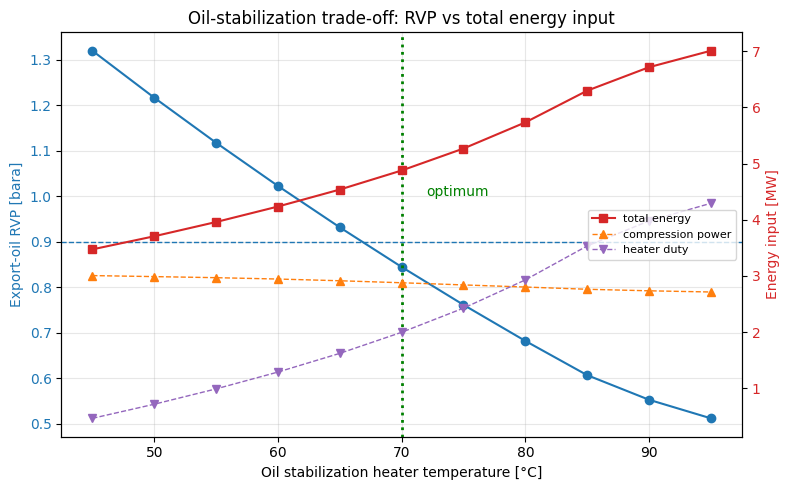

In [10]:
import matplotlib.pyplot as plt

Ts = [t["heater_T_C"] for t in trials]
rvps = [t["rvp_bara"] for t in trials]
energy = [t["total_energy_MW"] for t in trials]
comp_p = [t["total_power_MW"] for t in trials]
htr_q = [t["heater_duty_MW"] for t in trials]

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_title("Oil-stabilization trade-off: RVP vs total energy input")
ax1.set_xlabel("Oil stabilization heater temperature [\u00b0C]")
ax1.set_ylabel("Export-oil RVP [bara]", color="tab:blue")
ax1.plot(Ts, rvps, "o-", color="tab:blue", label="RVP")
ax1.axhline(RVP_LIMIT_BARA, color="tab:blue", ls="--", lw=1, label=f"RVP limit {RVP_LIMIT_BARA} bara")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel("Energy input [MW]", color="tab:red")
ax2.plot(Ts, energy, "s-", color="tab:red", label="total energy")
ax2.plot(Ts, comp_p, "^--", color="tab:orange", lw=1, label="compression power")
ax2.plot(Ts, htr_q, "v--", color="tab:purple", lw=1, label="heater duty")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.legend(loc="center right", fontsize=8)

ax1.axvline(best["heater_T_C"], color="green", ls=":", lw=2)
ax1.annotate("optimum", xy=(best["heater_T_C"], RVP_LIMIT_BARA),
             xytext=(best["heater_T_C"] + 2, RVP_LIMIT_BARA + 0.1), color="green")
fig.tight_layout()
plt.savefig("plant_optimization_tradeoff.png", dpi=120, bbox_inches="tight")
plt.show()

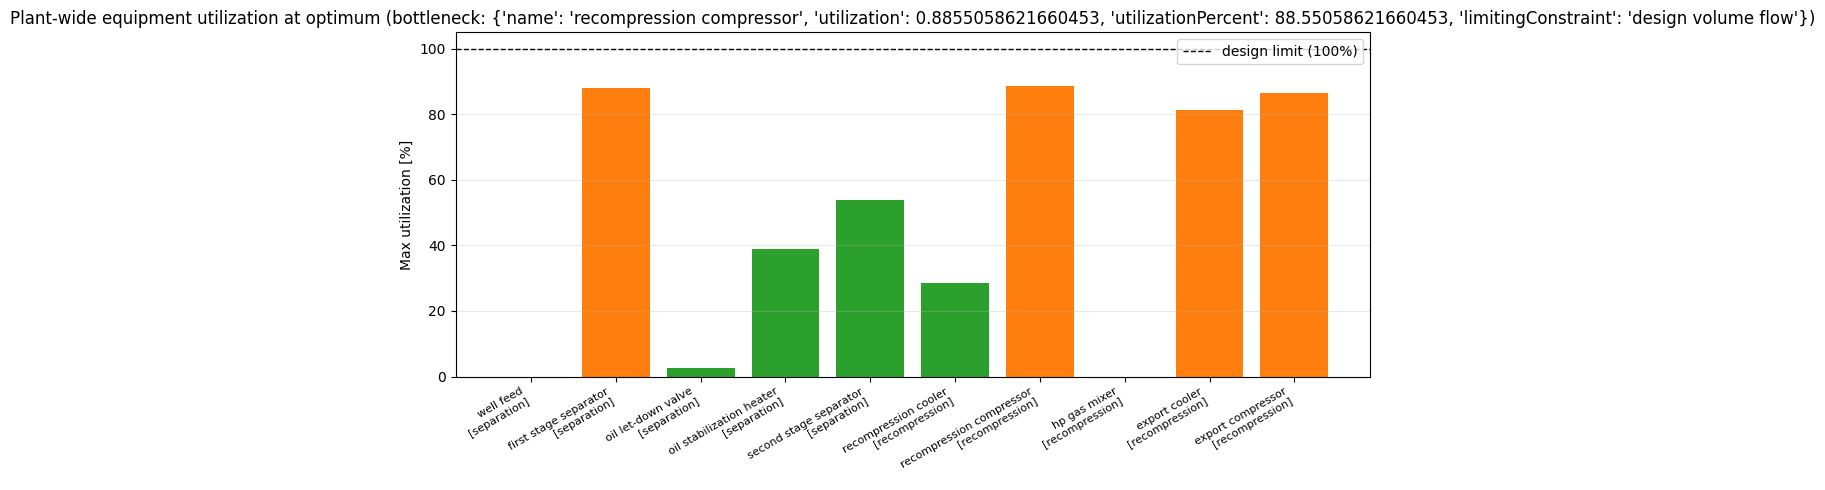

In [11]:
# Utilization bar chart at the optimum operating point.
evaluate_trial(best["heater_T_C"])  # restore the optimum state
snap = j(plant.getUtilizationSnapshotJson())
names = [f"{u.get('name')}\n[{u.get('area','-')}]" for u in snap.get("units", [])]
utils = [u.get("maxUtilizationPercent", 0) for u in snap.get("units", [])]
colors = ["tab:red" if v > 100 else ("tab:orange" if v > 80 else "tab:green") for v in utils]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(names)), utils, color=colors)
ax.axhline(100, color="k", ls="--", lw=1, label="design limit (100%)")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Max utilization [%]")
ax.set_title(f"Plant-wide equipment utilization at optimum (bottleneck: {snap.get('bottleneck')})")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.savefig("plant_optimization_utilization.png", dpi=120, bbox_inches="tight")
plt.show()

In [12]:
# Persist a machine-readable result summary.
results = {
    "model": "self-contained 2-area ProcessModel (separation + recompression)",
    "reference_pattern": "Oseberg Sture low-pressure operation (multi-area ProcessModel)",
    "decision_variable": {"address": heater_addr, "unit": "C", "range_C": [45, 95]},
    "rvp_limit_bara": RVP_LIMIT_BARA,
    "objective": "minimise total energy input (compression power + heater duty) subject to RVP <= limit",
    "optimum": {
        "oil_heater_temperature_C": best["heater_T_C"],
        "export_oil_rvp_bara": round(best["rvp_bara"], 4),
        "total_compression_power_MW": round(best["total_power_MW"], 4),
        "heater_duty_MW": round(best["heater_duty_MW"], 4),
        "total_energy_MW": round(best["total_energy_MW"], 4),
        "bottleneck": best["bottleneck"],
    },
    "trials": trials,
    "constraints_registered": int(n_constraints),
}
with open("plant_optimization_results.json", "w", encoding="utf-8") as fh:
    json.dump(results, fh, indent=2)
print("Saved plant_optimization_results.json")
print(json.dumps(results["optimum"], indent=2))

Saved plant_optimization_results.json
{
  "oil_heater_temperature_C": 70.0,
  "export_oil_rvp_bara": 0.8445,
  "total_compression_power_MW": 2.8793,
  "heater_duty_MW": 1.9977,
  "total_energy_MW": 4.877,
  "bottleneck": {
    "name": "recompression compressor",
    "utilization": 0.8855058621660453,
    "utilizationPercent": 88.55058621660453,
    "limitingConstraint": "design volume flow"
  }
}


## Summary

This notebook demonstrated the **complete plant-wide optimization workflow** on a multi-area
`ProcessModel`:

1. **Build** named process areas and compose them with `ProcessModel.add()`.
2. **Observe** that utilization is zero until design limits exist (`getUtilizationSnapshotJson()`).
3. **Size** the whole plant with `autoSizeEquipment(safety)`.
4. **Activate** utilization across the entire plant with a single call to the new
   **`applyMechanicalDesignCapacityConstraints()`** helper (idempotent, safe to re-call).
5. **Discover** the bounded decision space with `getAdjustableParametersJson()`.
6. **Optimize** with the gated, never-throwing `evaluate()` step, gating on the `feasible` flag
   and handling the off-model RVP spec (`Standard_ASTM_D6377`) as a penalty.

For the real **Oseberg** model the only differences are scale (≈13 areas instead of 2) and the
decision vector (export/injection compressor pressures, stage pressures, heater temperatures,
compressor speeds) — every API call shown here transfers unchanged.